# 21. 새 과제 흐름: 피드백으로 새 기술 배우기

처음 보는 과제를 **풀면서 배우는** 힘을 외부 데이터로 재 봤어.

- 공개 분류 과제 6개가 차례로 와: SUBJ → AG News → TREC → SST-2 → TweetEval 감정 → Emotion.
- 과제마다 글이 하나씩 오고, 시스템이 답하면 바로 정답을 알려 줘(피드백). 따로 학습하는 단계는 없어.
- 조건 두 개: **이름 라벨**(진짜 라벨 이름이라 미리 아는 지식이 통함), **기호 라벨**(A, B, C…로 바꿔서 피드백에서 배우는 것만 통함).
- 지표는 온라인 정확도(흐름 전체 평균)를 과제 6개로 평균 낸 값. 봉인셋은 과제당 200개씩이야.

**누가 겨루나**
- **E2B 혼자 / E4B 혼자**: Gemma 4에 라벨 목록 + 이 과제의 최근 피드백 예시 16개 + 글을 주고 답을 받아.
- **MK1 v1**: 말하기 위성(E2B의 답) + 과제마다 키우는 부품(얼린 e5-small 눈 위의 클래스 평균) + 세는 중재자(이 과제에서 각 통로가 몇 번 맞혔는지로 저울질).
- **MK1 v2**: 똑같은데 키우는 부품의 눈만 bge-large로 바꾸고, 클래스 평균을 정규화하고 지금까지 본 글들의 평균을 빼서 비교해.

Gemma 결과는 저장된 답에서 같은 해석기로 다시 채점했어(모든 시스템이 같은 기준).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from cognitive_lab import summary_taskstream as T
from cognitive_lab import viz as V
V.setup()
COLOR = {"e2b": V.NEUTRAL, "e4b": V.ORANGE, "mk1": V.AQUA, "mk1-v2": V.BLUE}
LABEL = dict(T.SYSTEMS)
systems = [s for s, _ in T.SYSTEMS]
f3 = lambda v: f"{v + 1e-9:.3f}"  # round half up, as in the design doc
runs = {p: T.load(p) for p in ("dev", "final", "final2")}
acc = {p: T.accuracy(r) for p, r in runs.items()}
for p in acc:
    print(p.ljust(7), " | ".join(f"{LABEL[s]}: 이름 {f3(a['named'])}, 기호 {f3(a['symbolic'])}" for s, a in acc[p].items()))

dev     E2B 혼자: 이름 0.592, 기호 0.418 | E4B 혼자: 이름 0.755, 기호 0.595 | MK1 v1: 이름 0.640, 기호 0.577 | MK1 v2: 이름 0.715, 기호 0.688
final   E2B 혼자: 이름 0.610, 기호 0.429 | E4B 혼자: 이름 0.761, 기호 0.615 | MK1 v1: 이름 0.653, 기호 0.603
final2  E2B 혼자: 이름 0.660, 기호 0.441 | E4B 혼자: 이름 0.788, 기호 0.630 | MK1 v1: 이름 0.709, 기호 0.632 | MK1 v2: 이름 0.764, 기호 0.752


## 1. 봉인 final2 결과 한눈에

final2는 MK1 v2를 얼린 다음 한 번만 연 새 봉인셋이야. 아래 줄은 차이(왼쪽 − 오른쪽)와 짝지은 부트스트랩 95% 구간이야. 구간이 0을 안 걸치면 진짜 차이로 봐.

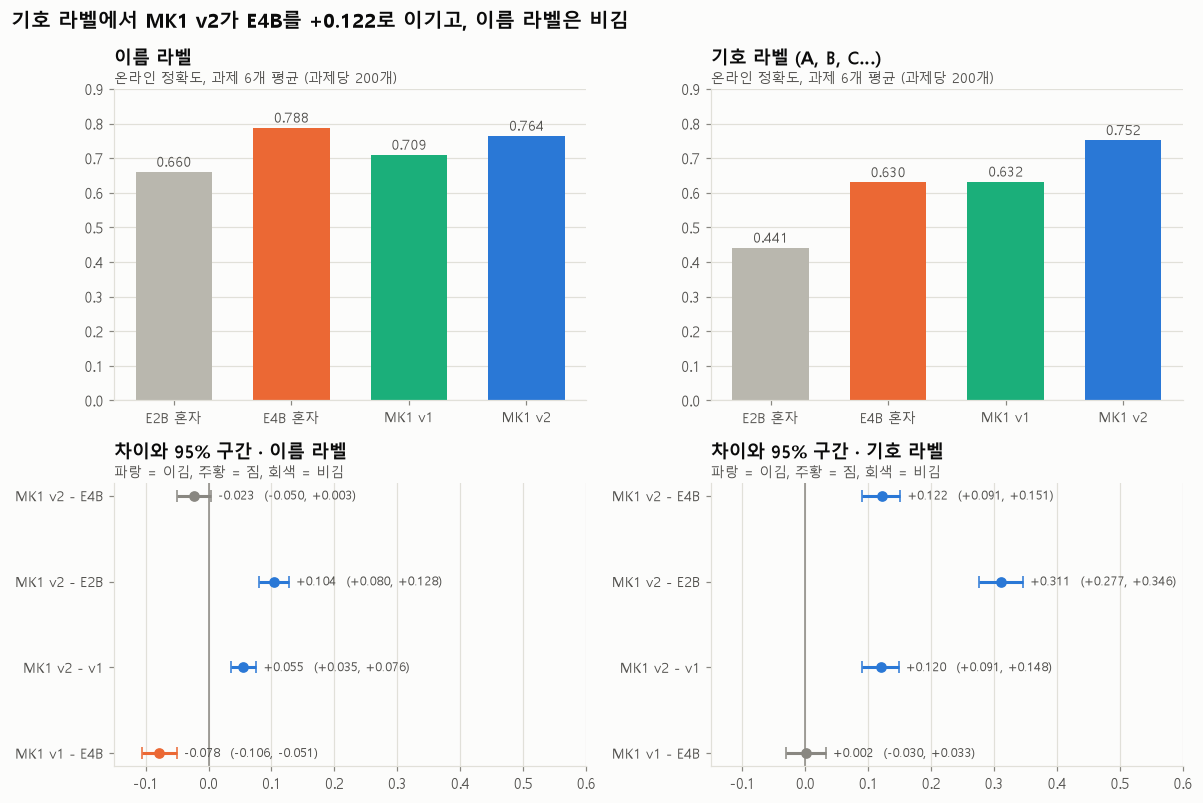

In [2]:
a, vd = acc["final2"], T.verdict("final2")["versus"]
fig, axes = plt.subplots(2, 2, figsize=(11, 7.4), gridspec_kw={"height_ratios": [1.1, 1]})
for col, (c, cname) in enumerate(T.CONDITIONS):
    ax = axes[0, col]
    vals = [a[s][c] for s in systems]
    ax.bar(range(4), vals, color=[COLOR[s] for s in systems], width=0.65)
    for i, v in enumerate(vals):
        ax.text(i, v + 0.015, f3(v), ha="center", fontsize=9, color=V.TEXT_SECONDARY)
    ax.set_xticks(range(4), [LABEL[s] for s in systems], fontsize=9); ax.set_ylim(0, 0.9); ax.grid(axis="x", visible=False)
    ax.set_title(cname, pad=16)
    V.note(ax, "온라인 정확도, 과제 6개 평균 (과제당 200개)")
pairs = [("mk1-v2 - e4b", "MK1 v2 - E4B"), ("mk1-v2 - e2b", "MK1 v2 - E2B"), ("mk1-v2 - mk1", "MK1 v2 - v1"), ("mk1 - e4b", "MK1 v1 - E4B")]
for col, (c, cname) in enumerate(T.CONDITIONS):
    ax = axes[1, col]
    for i, (k, name) in enumerate(pairs):
        d, (lo, hi) = vd[k][c]["difference"], vd[k][c]["ci95"]
        color = V.BLUE if lo > 0 else (V.ORANGE if hi < 0 else V.MUTED)
        ax.errorbar(d, i, xerr=[[d - lo], [hi - d]], fmt="o", color=color, capsize=4, lw=2)
        ax.text(hi + 0.012, i, f"{d:+.3f}  ({lo:+.3f}, {hi:+.3f})", va="center", fontsize=8.5, color=V.TEXT_SECONDARY)
    ax.axvline(0, color=V.MUTED, lw=1)
    ax.set_yticks(range(len(pairs)), [n for _, n in pairs], fontsize=9); ax.invert_yaxis()
    ax.set_xlim(-0.15, 0.6); ax.grid(axis="y", visible=False)
    ax.set_title("차이와 95% 구간 · " + cname.split(" ")[0] + " 라벨", pad=16)
    V.note(ax, "파랑 = 이김, 주황 = 짐, 회색 = 비김")
fig.suptitle("기호 라벨에서 MK1 v2가 E4B를 +0.122로 이기고, 이름 라벨은 비김", x=0.01, ha="left", fontsize=13, fontweight="bold", color=V.TEXT)
fig.tight_layout(); plt.show()

### 첫 번째 봉인셋(final)도 같이 보기

v2를 만들기 전에 MK1 v1을 얼리고 연 봉인셋이야. 여기서 v1은 E2B보다 두 조건 다 높았고(주 가설 통과), E4B에게 이름 라벨은 지고 기호 라벨은 비겼어. 그다음 키우는 부품의 눈을 고친 게 v2야.

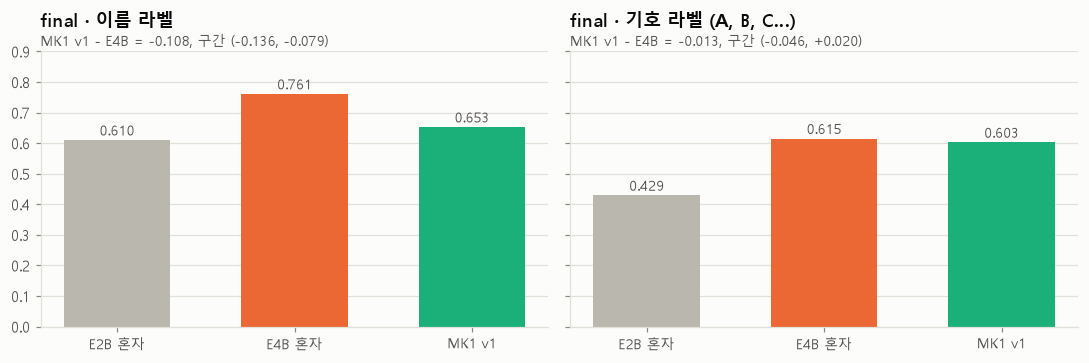

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4), sharey=True)
vf = T.verdict("final")["versus"]
for ax, (c, cname) in zip(axes, T.CONDITIONS):
    ss = [s for s in systems if s in acc["final"]]
    vals = [acc["final"][s][c] for s in ss]
    ax.bar(range(len(ss)), vals, color=[COLOR[s] for s in ss], width=0.6)
    for i, v in enumerate(vals):
        ax.text(i, v + 0.015, f3(v), ha="center", fontsize=9, color=V.TEXT_SECONDARY)
    ax.set_xticks(range(len(ss)), [LABEL[s] for s in ss], fontsize=9); ax.set_ylim(0, 0.9); ax.grid(axis="x", visible=False)
    ax.set_title("final · " + cname, pad=16)
    d = vf["mk1 - e4b"][c]
    V.note(ax, f"MK1 v1 - E4B = {d['difference']:+.3f}, 구간 ({d['ci95'][0]:+.3f}, {d['ci95'][1]:+.3f})")
fig.tight_layout(); plt.show()

## 2. 과제별로 보면 (기호 라벨, final2)

기호 라벨에선 라벨 이름이 아무 힌트도 안 주니까, 피드백에서 배운 만큼만 맞혀.

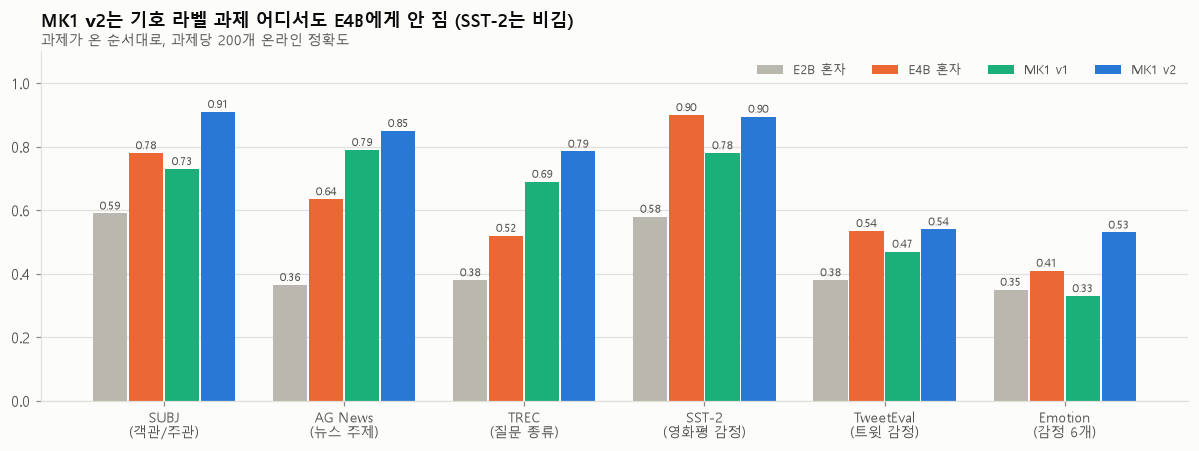

In [4]:
order = T.task_order("final2")
pt = T.per_task(runs["final2"], "symbolic")
fig, ax = plt.subplots(figsize=(11, 4.2))
x = np.arange(len(order)); w = 0.2
for i, s in enumerate(systems):
    vals = [pt[s][t] for t in order]
    ax.bar(x + (i - 1.5) * w, vals, width=w * 0.95, color=COLOR[s], label=LABEL[s])
    for xi, v in zip(x, vals):
        ax.text(xi + (i - 1.5) * w, v + 0.012, f"{v:.2f}", ha="center", fontsize=7, color=V.TEXT_SECONDARY)
ax.set_xticks(x, [T.TASK_NAMES[t] for t in order], fontsize=9); ax.set_ylim(0, 1.1); ax.grid(axis="x", visible=False)
ax.legend(ncol=4, fontsize=8.5, loc="upper right")
ax.set_title("MK1 v2는 기호 라벨 과제 어디서도 E4B에게 안 짐 (SST-2는 비김)", pad=16)
V.note(ax, "과제가 온 순서대로, 과제당 200개 온라인 정확도")
fig.tight_layout(); plt.show()

## 3. 배우는 모습: 흐름 위치별 정확도

이게 핵심 그림이야. 과제 안에서 글이 몇 번째로 왔는지(1~200)에 따라 정확도가 어떻게 바뀌는지 봐. 과제 6개를 평균 내고, 최근 20개로 이동 평균을 했어.

- 피드백에서 배우면 선이 **오른쪽으로 갈수록 올라가**.
- Gemma는 최근 예시 16개만 프롬프트에 넣으니까, 그 이상은 더 쌓을 데가 없어.

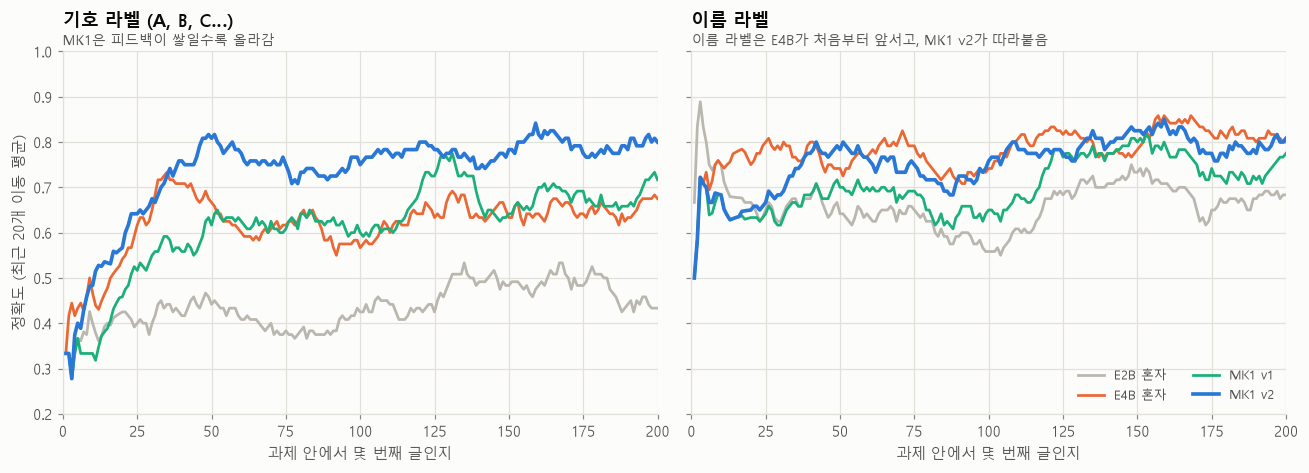

50개씩 끊은 정확도 (1-50, 51-100, 101-150, 151-200), 과제 6개 평균
이름 라벨
   E2B 혼자   0.657  0.607  0.707  0.670
   E4B 혼자   0.760  0.767  0.807  0.817
   MK1 v1   0.663  0.660  0.770  0.743
   MK1 v2   0.723  0.740  0.800  0.793
기호 라벨 (A, B, C…)
   E2B 혼자   0.417  0.407  0.470  0.470
   E4B 혼자   0.620  0.603  0.643  0.653
   MK1 v1   0.533  0.620  0.683  0.690
   MK1 v2   0.690  0.743  0.780  0.793


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), sharey=True)
for ax, (c, cname) in zip(axes, [T.CONDITIONS[1], T.CONDITIONS[0]]):
    cv = T.curve(runs["final2"], c, window=20)
    for s in systems:
        n, y = cv[s]
        ax.plot(n, y, color=COLOR[s], lw=2.4 if s == "mk1-v2" else 1.8, label=LABEL[s])
    ax.set_xlim(0, 200); ax.set_ylim(0.2, 1.0); ax.set_xlabel("과제 안에서 몇 번째 글인지")
    ax.set_title(cname, pad=16)
axes[0].set_ylabel("정확도 (최근 20개 이동 평균)")
V.note(axes[0], "MK1은 피드백이 쌓일수록 올라감")
V.note(axes[1], "이름 라벨은 E4B가 처음부터 앞서고, MK1 v2가 따라붙음")
axes[1].legend(fontsize=8.5, loc="lower right", ncol=2)
fig.tight_layout(); plt.show()

blk = {c: T.blocks(runs["final2"], c, 50) for c, _ in T.CONDITIONS}
print("50개씩 끊은 정확도 (1-50, 51-100, 101-150, 151-200), 과제 6개 평균")
for c, cname in T.CONDITIONS:
    print(cname)
    for s in systems:
        print("  ", LABEL[s].ljust(8), "  ".join(f"{v:.3f}" for v in blk[c][s]))

## 4. 키우는 부품의 눈 고르기 (개발용)

v1 → v2의 차이는 "눈"이야. 키우는 부품만 혼자 돌려서(기호 라벨, 과제당 100개) 눈과 비교 방식을 바꿔 봤어.

- 정규화 = 클래스 평균의 길이를 1로 맞추기. 중심 맞추기 = 지금까지 본 글들의 평균을 빼고 비교(과거만 씀).
- 처음에 "중심 맞추기 +0.04"라고 했던 건 대부분 **정규화** 효과였어(정정).
- E2B 내부 표현은 감정 과제에서 우연보다 낮았어(0.07). LLM 임베딩이 한쪽으로 쏠려 있어서야.
- 후보 네 개 중 개발용 최고를 골랐으니 이 숫자는 조금 낙관적이야. 판정은 봉인 final2로 했어.

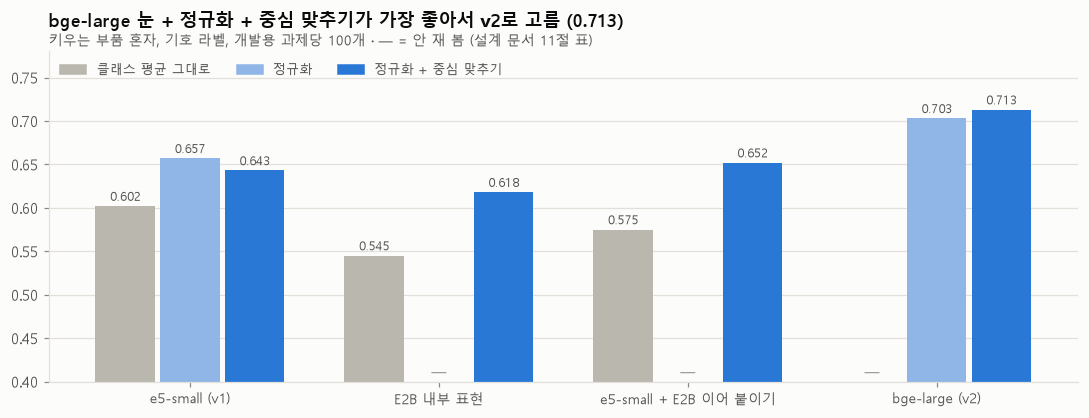

In [6]:
settings = ["클래스 평균 그대로", "정규화", "정규화 + 중심 맞추기"]
shade = [V.NEUTRAL, "#8fb6e6", V.BLUE]
fig, ax = plt.subplots(figsize=(10, 3.9))
x = np.arange(len(T.EYES)); w = 0.26
for j, (name, color) in enumerate(zip(settings, shade)):
    for i, row in enumerate(T.EYES):
        v = row[1 + j]
        if v is None:
            ax.text(i + (j - 1) * w, 0.405, "—", ha="center", fontsize=10, color=V.MUTED)
            continue
        ax.bar(i + (j - 1) * w, v, width=w * 0.92, color=color)
        ax.text(i + (j - 1) * w, v + 0.006, f"{v:.3f}", ha="center", fontsize=8, color=V.TEXT_SECONDARY)
from matplotlib.patches import Patch
ax.legend([Patch(color=c) for c in shade], settings, fontsize=8.5, loc="upper left", ncol=3)
ax.set_xticks(x, [r[0] for r in T.EYES], fontsize=9); ax.set_ylim(0.4, 0.78); ax.grid(axis="x", visible=False)
ax.set_title("bge-large 눈 + 정규화 + 중심 맞추기가 가장 좋아서 v2로 고름 (0.713)", pad=16)
V.note(ax, "키우는 부품 혼자, 기호 라벨, 개발용 과제당 100개 · — = 안 재 봄 (설계 문서 11절 표)")
fig.tight_layout(); plt.show()

## 5. 정리

- **주 가설 통과**: 기호 라벨(처음 보는 과제를 피드백으로만 배워야 함)에서 MK1 v2 − E4B = **+0.122**, 구간 (+0.091, +0.151). 2B급 말하기 위성 + 0.34B 눈 위에서 과제마다 키우는 부품이 4B급 단일 모델의 프롬프트 속 학습(예시 16개)을 이겼어.
- **부 가설 통과**: 눈만 바꿨더니 v2 − v1 = 이름 +0.055, 기호 +0.120. 같은 구조에서 부품만 바꿔 끼워 키울 수 있다는 것(모듈 교체 = 성장)도 확인했어.
- **이름 라벨**(미리 아는 지식)은 여전히 E4B가 조금 앞서지만(−0.023), 이제 차이가 구간 안이라 비김이야.
- 첫 봉인셋(final)에선 v1이 E2B는 이기고, E4B에게 이름 라벨은 지고 기호 라벨은 비겼어. final2에서도 v1은 기호 라벨에서 E4B와 비겼어(+0.002).
- 주의: BGE는 학습 때 공개 분류 데이터의 학습 split을 봤을 수 있어(시험 split은 아님). Gemma의 사전 지식과 같은 급으로 봐.